# Test Lensing models

In [2]:
# including packages
using PyPlot
using PSFModels

ERROR: LoadError: ArgumentError: Package ADTypes [47edcb42-4c32-4615-8424-f2b9edc5f35b] is required but does not seem to be installed:
 - Run `Pkg.instantiate()` to install all recorded dependencies.

Stacktrace:
  [1] _require(pkg::Base.PkgId, env::String)
    @ Base ./loading.jl:1989
  [2] __require_prelocked(uuidkey::Base.PkgId, env::String)
    @ Base ./loading.jl:1875
  [3] #invoke_in_world#3
    @ ./essentials.jl:926 [inlined]
  [4] invoke_in_world
    @ ./essentials.jl:923 [inlined]
  [5] _require_prelocked(uuidkey::Base.PkgId, env::String)
    @ Base ./loading.jl:1866
  [6] macro expansion
    @ ./loading.jl:1853 [inlined]
  [7] macro expansion
    @ ./lock.jl:267 [inlined]
  [8] __require(into::Module, mod::Symbol)
    @ Base ./loading.jl:1816
  [9] #invoke_in_world#3
    @ ./essentials.jl:926 [inlined]
 [10] invoke_in_world
    @ ./essentials.jl:923 [inlined]
 [11] require(into::Module, mod::Symbol)
    @ Base ./loading.jl:1809
 [12] include
    @ ./Base.jl:495 [inlined]
 [13

ErrorException: Failed to precompile PSFModels [9ba017d1-7760-46cd-84a3-1e79e9ae9ddc] to "/home/cyan/.julia/compiled/v1.10/PSFModels/jl_99VDDQ".

In [18]:
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG

# Lens instance

In [19]:
image_para = Dict(
    :num => 50,
    :deltap => 0.09,
    :redshift => 1.0,
    :bkg_noise => 0.5,
    :exp_time => 90,
)

Dict{Symbol, Real} with 5 entries:
  :num       => 50
  :deltap    => 0.09
  :bkg_noise => 0.5
  :redshift  => 1.0
  :exp_time  => 90

In [20]:
x = range(-2, 2, 101)
xg, yg = LazyGrids.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.96 -1.96 … -1.96 -1.96; … ; 1.96 1.96 … 1.96 1.96; 2.0 2.0 … 2.0 2.0], [-2.0 -1.96 … 1.96 2.0; -2.0 -1.96 … 1.96 2.0; … ; -2.0 -1.96 … 1.96 2.0; -2.0 -1.96 … 1.96 2.0])

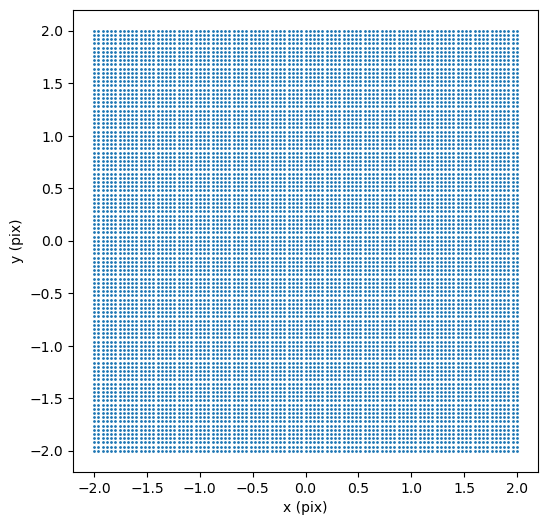

In [21]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(xg, yg, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [22]:
PyPlot.clf()

# SIS

In [1]:
using Jens.LensModel:SISreal as SISreal
using Jens.LensModel:SIS as SIS
# using Jens.LensModel:SIS as SIS

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [7]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

([-1.3095242533174993 -1.3029216067081926 … -1.2335766423357664 -1.2407433976347035; -1.2765004711258383 -1.2698430493494786 … -1.1997022724966986 -1.2069705916363591; … ; 1.3143690173539018 1.3074768646401225 … 1.233636974173642 1.2413978582334093; 1.3463801296539077 1.3395288446611344 … 1.26638192514476 1.2740473160941734], [-1.2766444558564278 -1.2430050811855693 … 1.3176642335766422 1.3492086265440315; -1.2700490468334196 -1.236340284754793 … 1.3104252425214513 1.3420131383230323; … ; -1.2363504506336471 -1.202231197646594 … 1.272688749755704 1.3045785724839445; -1.2431769922308404 -1.2091485812989737 … 1.2804379938183037 1.3122553520892168])

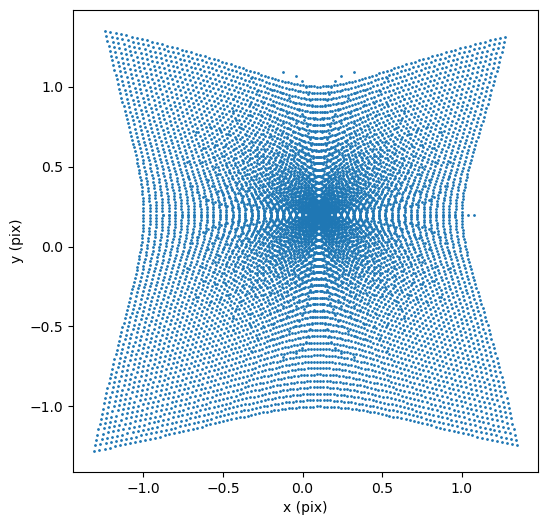

In [8]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [10]:
SIS.LensPotential

LensPotential (generic function with 1 method)

In [11]:
m = SIS.LensPotential(xg, yg; LensParaDict...);

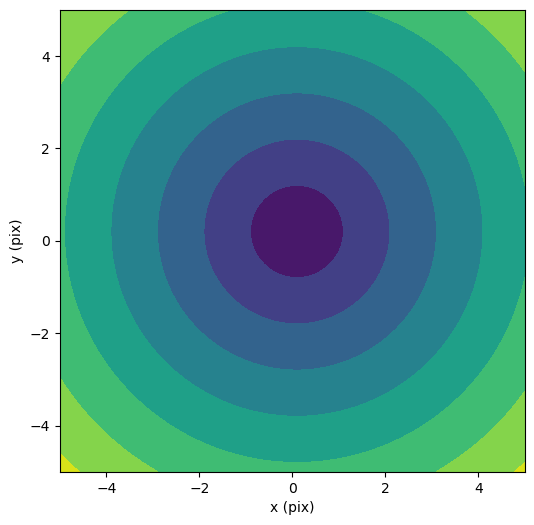

In [12]:
PyPlot.contourf(xg, yg, m)
gcf()

# benchmark comparison

In [3]:
using BenchmarkTools

In [11]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

([-1.3095242533174993 -1.3029216067081926 … -1.2335766423357664 -1.2407433976347035; -1.2765004711258383 -1.2698430493494786 … -1.1997022724966986 -1.2069705916363591; … ; 1.3143690173539018 1.3074768646401225 … 1.233636974173642 1.2413978582334093; 1.3463801296539077 1.3395288446611344 … 1.26638192514476 1.2740473160941734], [-1.2766444558564278 -1.2430050811855693 … 1.3176642335766422 1.3492086265440315; -1.2700490468334196 -1.236340284754793 … 1.3104252425214513 1.3420131383230323; … ; -1.2363504506336471 -1.202231197646594 … 1.272688749755704 1.3045785724839445; -1.2431769922308404 -1.2091485812989737 … 1.2804379938183037 1.3122553520892168])

In [12]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SISreal, LensKwargs=LensParaDict)

([-1.3095242533174993 -1.3029216067081926 … -1.2335766423357664 -1.2407433976347035; -1.2765004711258383 -1.2698430493494786 … -1.1997022724966986 -1.2069705916363591; … ; 1.3143690173539018 1.3074768646401225 … 1.233636974173642 1.2413978582334093; 1.3463801296539077 1.3395288446611344 … 1.26638192514476 1.2740473160941734], [-1.2766444558564278 -1.2430050811855693 … 1.3176642335766422 1.3492086265440315; -1.2700490468334196 -1.236340284754793 … 1.3104252425214513 1.3420131383230323; … ; -1.2363504506336471 -1.202231197646594 … 1.272688749755704 1.3045785724839445; -1.2431769922308404 -1.2091485812989737 … 1.2804379938183037 1.3122553520892168])

In [13]:
@benchmark  LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   77.917 μs …   3.556 ms  ┊ GC (min … max):  0.00% … 97.06%
 Time  (median):     104.375 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   121.403 μs ± 126.089 μs  ┊ GC (mean ± σ):  12.25% ± 11.59%

    █                                                            
  ▃▃█▅▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▂▂▂▁▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂ ▂
  77.9 μs          Histogram: frequency by time          788 μs <

 Memory estimate: 816.64 KiB, allocs estimate: 68.

In [14]:
@benchmark  LB.LensPlane(xg, yg; LensModel=SISreal, LensKwargs=LensParaDict)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   78.291 μs …   3.586 ms  ┊ GC (min … max):  0.00% … 96.01%
 Time  (median):     111.458 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   132.092 μs ± 164.934 μs  ┊ GC (mean ± σ):  14.53% ± 11.10%

   █▁                                                            
  ▃██▃▂▂▂▂▁▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▂▁▂▁▂▂▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂ ▂
  78.3 μs          Histogram: frequency by time         1.21 ms <

 Memory estimate: 816.64 KiB, allocs estimate: 68.

These tests show the SIS(::Real) shares the silimar speed with SIS(::Float64).

# Shear

In [13]:
using Jens.LensModel:Shear as Shear

In [14]:
LensParaDict = Dict(:gamma1=>0.1, :gamma2=>0.1,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=Shear, LensKwargs=LensParaDict)

([-3.99 -4.0 … -4.98 -4.99; -3.9000000000000004 -3.91 … -4.890000000000001 -4.9; … ; 4.92 4.91 … 3.93 3.9200000000000004; 5.01 5.0 … 4.02 4.01], [-4.99 -4.880000000000001 … 5.9 6.01; -5.0 -4.890000000000001 … 5.890000000000001 6.0; … ; -5.98 -5.870000000000001 … 4.91 5.02; -5.99 -5.880000000000001 … 4.9 5.01])

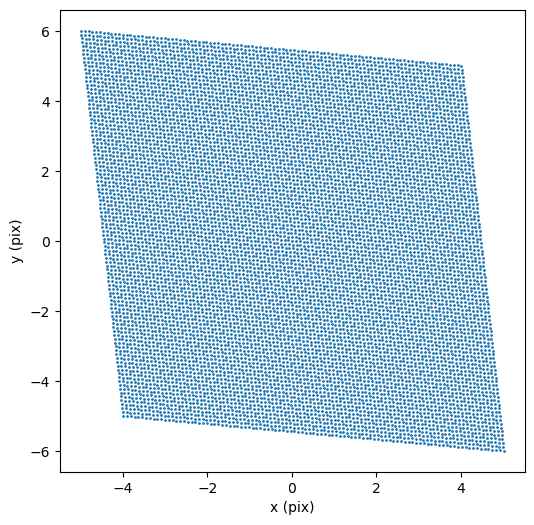

In [15]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Major-axes NIE model

In [42]:
using Jens.LensModel:NIEkappa as NIEkappa

In [249]:
# NIE model 
LensParaDict = Dict(:b => 1.5, :s => 0.1,
 :q => 0.4, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.4084429312700584 -3.3978409984042632 … -3.889364210238933 -3.9120760386372533; -3.3192128330532733 -3.3085271570906194 … -3.811922232320483 -3.8346519128492336; … ; 3.88117451145366 3.858461101944717 … 3.3308099902428974 3.341653294184969; 3.957684410395121 3.934954008254963 … 3.419513832272912 3.4302800807040947], [-3.0456637687517105 -2.956881465714677 … 3.2738536673550587 3.350155220102071; -3.035081687818215 -2.9461756994943515 … 3.2509141964693833 3.3276504915773994; … ; -3.282656178148457 -3.2049981866926123 … 2.9245112147950962 3.013683928397703; -3.305145082315224 -3.2279564837411727 … 2.935384526309207 3.024420603551887])

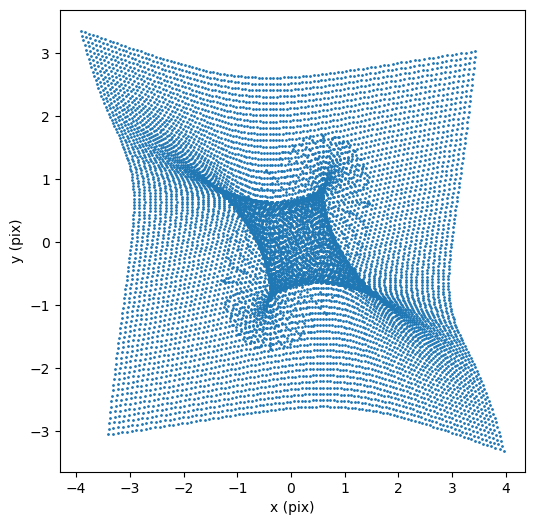

In [250]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [251]:
PyPlot.clf()

In [57]:
# NIE model 1
LensParaDict1 = Dict(:b => 0.6, :s => 0.1,
 :q => 0.2, :varphi =>  - pi/3. ,
  :xcentre => -1.5, :ycentre => 1.);
# NIE model 2
LensParaDict2 = Dict(:b => 0.6, :s => 0.1,
 :q => 0.2, :varphi =>  pi/6. ,
  :xcentre => 2, :ycentre => -1);
betax2, betay2 = LB.MultiLensRayShooting(xg, yg; 
            LensModel = [NIEkappa, NIEkappa],
            LensKwargs = [LensParaDict1, LensParaDict2])

TypeError: TypeError: in keyword argument LensKwargs, expected Vector{Dict{Symbol, Float64}}, got a value of type Vector{Dict{Symbol}}

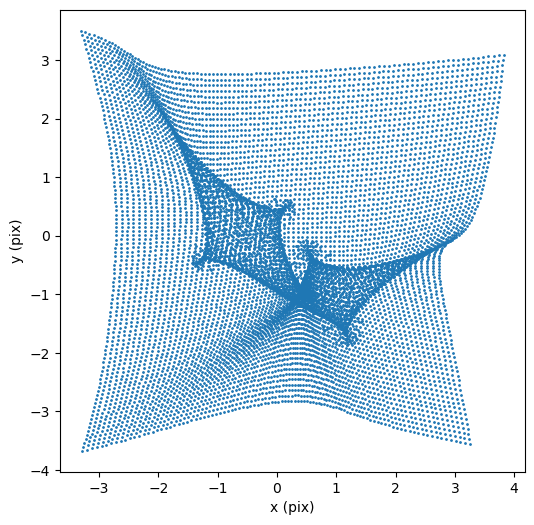

In [45]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [49]:
PyPlot.clf()

## Decouple multiple lenses 2

In [54]:
bx1, by1 = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict1)
bx2, by2 = LB.LensPlane(bx1, by1; LensModel=NIEkappa, LensKwargs=LensParaDict2)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.2268867916047235 -3.206348290841537 … -3.29778834652243 -3.3200747810627687; -3.1420849775400637 -3.121080689795282 … -3.22278380422015 -3.245924536417913; … ; 3.2516670757513815 3.2379800906220773 … 3.849998904720504 3.8572721070910707; 3.3332094594808344 3.319647093336995 … 3.933945280648548 3.941411155229063], [-3.7954954082836863 -3.730625013817394 … 3.411133395469478 3.490555129779211; -3.776448619567553 -3.711972269099782 … 3.3888863386322896 3.4680994189473444; … ; -3.495393886746866 -3.4083084864663657 … 2.9420848857643267 3.0349315481967003; -3.5098164017617037 -3.42277241889425 … 2.950117492587039 3.042826013096656])

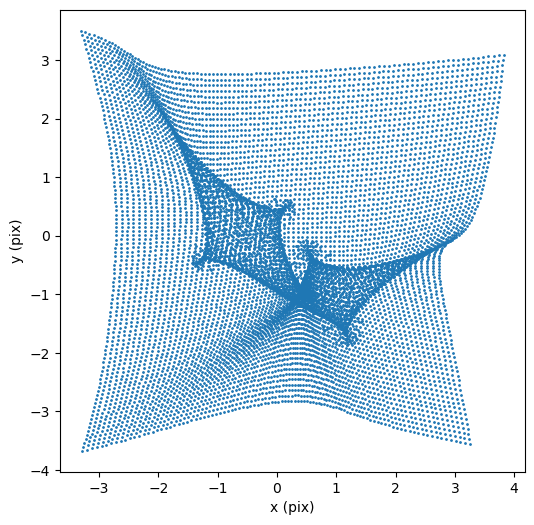

In [55]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [56]:
PyPlot.clf()

# NIE model

In [254]:
using Jens.LensModel:NIE as NIE

In [257]:
# NIE model 
LensParaDict = Dict(:theta_E => 2., :s_scale => 0.1,
 :e1 => 0.2, :e2 =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIE, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-4.0080420711121745 -3.9902708799997453 … -3.6598332423423923 -3.6694001979032276; -3.9259549946618653 -3.908135598600845 … -3.569653380734747 -3.579292986310315; … ; 3.599892393982574 3.5901168419465326 … 3.9450975429395045 3.9629768916921497; 3.6894545288510483 3.679745286280731 … 4.026409742593342 4.0442653894006195], [-3.5901411134737855 -3.508901598657034 … 3.28418943596343 3.373888376150993; -3.5724956057015893 -3.490954901948052 … 3.274530510977229 3.3643405093661096; … ; -3.3450430598344827 -3.254993592789999 … 3.454926357800522 3.5371101048473754; -3.3547243276821925 -3.2647975278973185 … 3.472959047653689 3.5548145444587274])

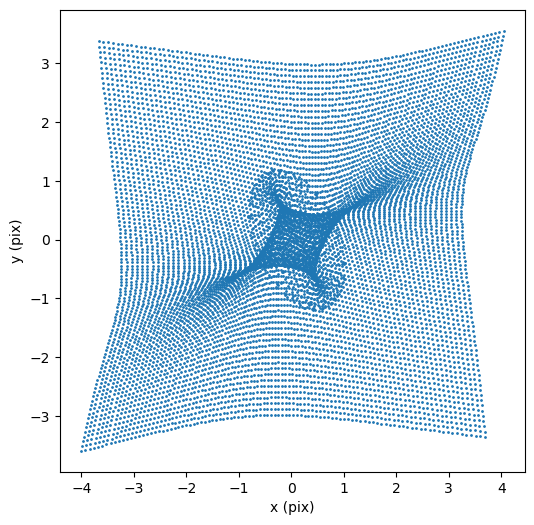

In [258]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Point mass

In [259]:
using Jens.LensModel:PointMass as PointMass

In [260]:
LensParaDict = Dict(:theta_E => 0.3, :xcentre => 0., :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=PointMass, LensKwargs=LensParaDict)

([-4.991 -4.990818200367272 … -4.990818200367272 -4.991; -4.891001836359927 -4.890816326530612 … -4.890816326530612 -4.891001836359927; … ; 4.891001836359927 4.890816326530612 … 4.890816326530612 4.891001836359927; 4.991 4.990818200367272 … 4.990818200367272 4.991], [-4.991 -4.891001836359927 … 4.891001836359927 4.991; -4.990818200367272 -4.890816326530612 … 4.890816326530612 4.990818200367272; … ; -4.990818200367272 -4.890816326530612 … 4.890816326530612 4.990818200367272; -4.991 -4.891001836359927 … 4.891001836359927 4.991])

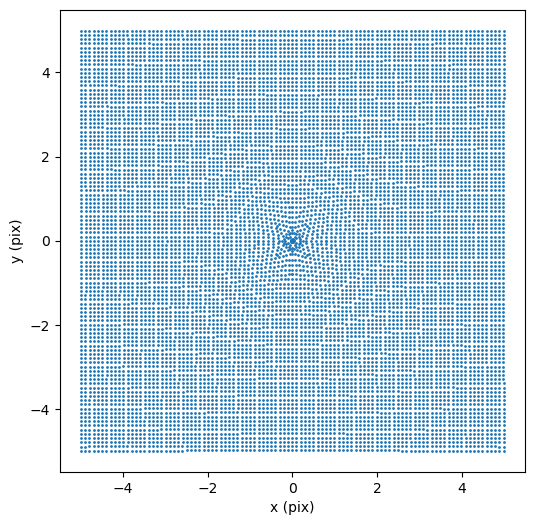

In [261]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# SIE model

In [262]:
using Jens.LensModel:SIE as SIE

In [265]:
LensParaDict = Dict(:b => 2., :s => 0.01,
 :q => 0.6, :varphi =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIE, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.5389621445648984 -3.518941405901267 … -3.3174372463710924 -3.332627731496515; -3.458730585478888 -3.4386045260841533 … -3.2323657060018354 -3.2476684492746783; … ; 3.2789902074543336 3.263479312806858 … 3.4794522331784625 3.4997583484590775; 3.3631189171871965 3.347709194977056 … 3.558771338820116 3.5789927671425366], [-3.0376175729535673 -2.9582857825863247 … 2.8207297990438844 2.905038577911608; -3.0176921993921137 -2.9380631449734187 … 2.805386600235077 2.8898880560354243; … ; -2.8592781832442125 -2.77436194520763 … 2.8973055951533535 2.977571556578584; -2.8746327132370766 -2.789928834850549 … 2.9177329962348213 2.9976734060143566])

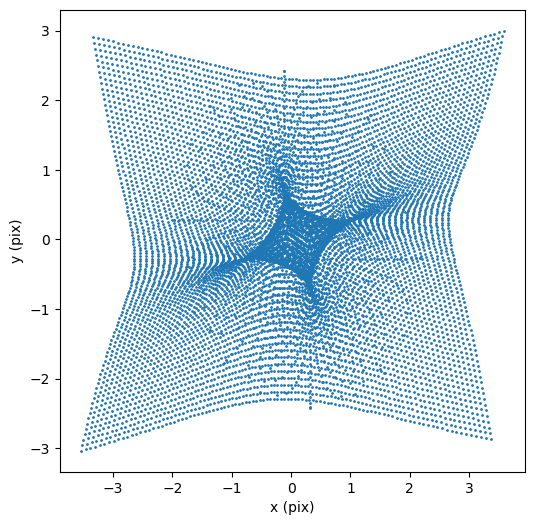

In [266]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# EPL model

In [267]:
using Jens.LensModel:EPL as EPL

In [270]:
LensParaDict = Dict(:theta_E => 1., :gamma => 0.1,
:e1 => 0.1, :e2 =>  0.2,
  :xcentre => 0.1, :ycentre => .1);
betax, betay = LB.LensPlane(xg, yg; LensModel=EPL, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()

([19.45520282384194 19.009620990064796 … 0.5601712043943543 0.34992657528593174; 19.097608492650423 18.652170830466282 … 0.26056330490658386 0.049448934537378975; … ; 1.1737145075534317 0.9507549523553829 … -16.89446865686415 -17.323993964565936; 0.8836127576101385 0.6617214309012924 … -17.2355785014991 -17.665248581012637], [2.3518793663420716 1.8361407346431617 … -57.63505374073716 -58.87953697810125; 2.697644393096283 2.1804041172072397 … -56.568624182501054 -57.805105584003904; … ; 58.38114225471757 57.127531663455855 … -1.6519924562873092 -2.147221032541207; 59.448699002174834 58.187117753767794 … -1.320051009556452 -1.813771882247778])

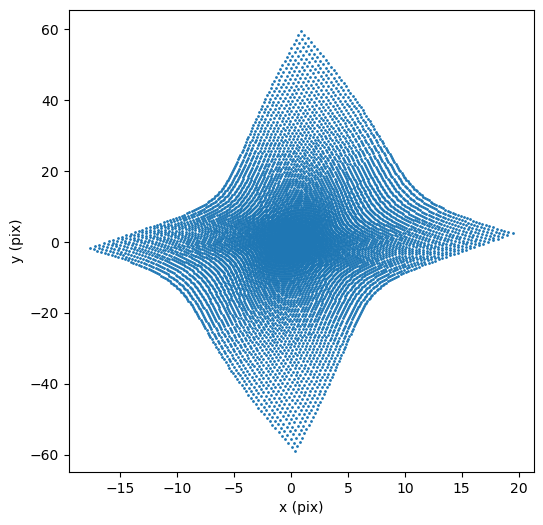

In [271]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NFW (spherical)

In [138]:
using Jens.LensModel:NFW as NFW

In [139]:
LensParaDict = Dict(:Rs=>2.0, :alpha_Rs=>0.5,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFW, LensKwargs=LensParaDict)

([-3.6695393878736384 -3.6655520332697042 … -3.6655520332697042 -3.6695393878736384; -3.5919776256526883 -3.587947676468095 … -3.587947676468095 -3.5919776256526883; … ; 3.5986046427479557 3.5944741838826872 … 3.5944741838826872 3.5986046427479557; 3.6758603577471134 3.6717689728622602 … 3.6717689728622602 3.6758603577471134], [-3.67759940280355 -3.6002351147359124 … 3.6002351147359124 3.67759940280355; -3.673609577763869 -3.5962076845161524 … 3.5962076845161524 3.673609577763869; … ; -3.6634603588983827 -3.585952565659721 … 3.585952565659721 3.6634603588983827; -3.6675490848688344 -3.5900857368256567 … 3.5900857368256567 3.6675490848688344])

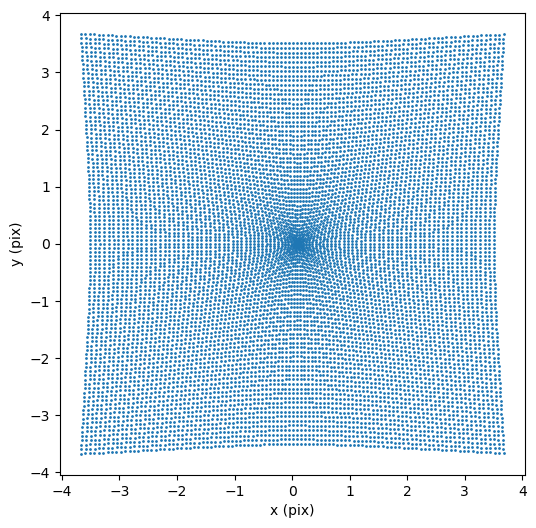

In [140]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NFW (elliptical)

In [141]:
using Jens.LensModel:NFWE as NFWE

In [142]:
LensParaDict = Dict(:Rs=>1.5, :alpha_Rs=>1., :e1=>0.3, :e2=>0.2,
  :xcentre => 0.4, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFWE, LensKwargs=LensParaDict)

([-3.5905093310293212 -3.5783496924045575 … -3.579505762950902 -3.5855005965638673; -3.5193396909504333 -3.50727070720582 … -3.5020704650327845 -3.508060988811145; … ; 3.537822640591644 3.531986045485789 … 3.6032128646844437 3.6138748717900255; 3.6144842028169357 3.608621945447422 … 3.6731336882332886 3.6839762053109917], [-3.224122943002925 -3.145750132045999 … 3.2696704035700286 3.3504751616258535; -3.218856519766672 -3.1402364432567094 … 3.2658875975828248 3.346757802340686; … ; -3.308708599893709 -3.2271179383674813 … 3.0918279176750456 3.172873451663434; -3.312574241167548 -3.231060906392919 … 3.096055886929073 3.176868255693746])

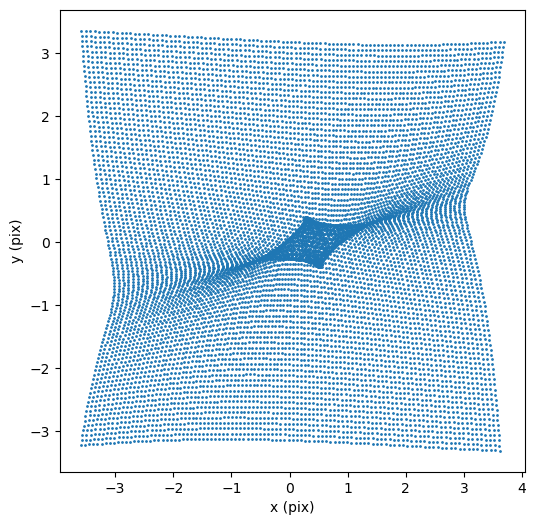

In [143]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Gaussian

In [23]:
using Jens.LensModel:Gaussian as GaussianModel

In [29]:
LensParaDict = Dict(:kappa0=>0.5, :q=>0.5, :sigma=>0.5, :varphi=>0.,
  :xcentre => 0.0, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=GaussianModel, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()

([-1.8882978043285565 -1.8860033986316798 … -1.8860033986316798 -1.8882978043285565; -1.8488975875482543 -1.846584188510594 … -1.846584188510594 -1.8488975875482543; … ; 1.8488975875482543 1.846584188510594 … 1.846584188510594 1.8488975875482543; 1.8882978043285565 1.8860033986316798 … 1.8860033986316798 1.8882978043285565], [-2.1329411973351924 -2.0935000806186497 … 2.0935000806186497 2.1329411973351924; -2.1352158970216886 -2.0958337043362962 … 2.0958337043362962 2.1352158970216886; … ; -2.1352158970216886 -2.0958337043362962 … 2.0958337043362962 2.1352158970216886; -2.1329411973351924 -2.0935000806186497 … 2.0935000806186497 2.1329411973351924])

Matrix{Float64}(101, 101)Float64()

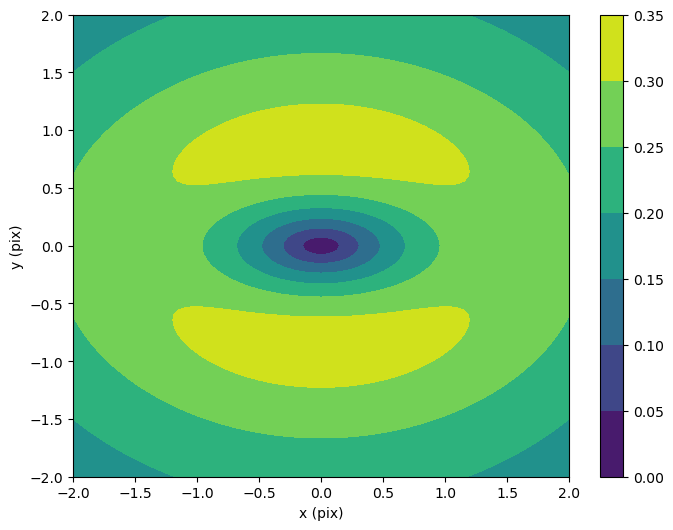

In [30]:
# Gaussian deflection angle
alphax, alphay = GaussianModel.LensDerivative(xg, yg; LensParaDict...)
FigLnes = PyPlot.figure(figsize=(8, 6))
PyPlot.contourf(xg, yg, sqrt.(alphax.^2 .+alphay.^2))
PyPlot.colorbar()
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [31]:
PyPlot.clf()

In [32]:
alpha = sqrt.(alphax.^2 .+alphay.^2);
size(alpha[alpha .< 0.1])

(89,)

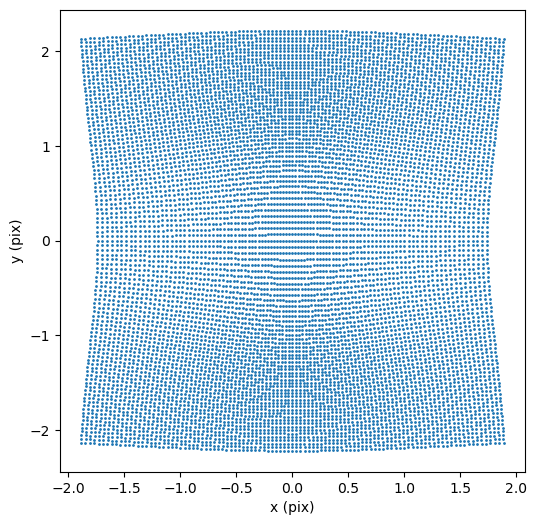

In [33]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [34]:
PyPlot.clf()

In [1]:
LensParaDict2 = Dict(:kappa0=>1., :q=>0.3, :sigma=>0.5, :varphi=>pi/4,
  :xcentre => 0., :ycentre => .0);
betax2, betay2 = LB.LensPlane(betax, betay; LensModel=GaussianModel, LensKwargs=LensParaDict2)

UndefVarError: UndefVarError: `GaussianModel` not defined

In [2]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

UndefVarError: UndefVarError: `PyPlot` not defined

In [241]:
PyPlot.clf()

In [68]:
kappalist = [0.5, 0.4, 0.3, 0.2, 0.02]
philist = [pi/4, pi, pi/3, -pi/3, -pi]
qlist = [0.5, 0.4, 0.3, 0.4, 0.2]
betax, betay = xg, yg
for i in 1:length(kappalist)
    LensParaDict = Dict(:kappa0=>kappalist[i], :q=>qlist[i], :sigma=>0.5, :varphi=>philist[i],:xcentre => 0.01, :ycentre => .01);
    betax, betay = LB.LensPlane(betax, betay; LensModel=GaussianModel, LensKwargs=LensParaDict)
end

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

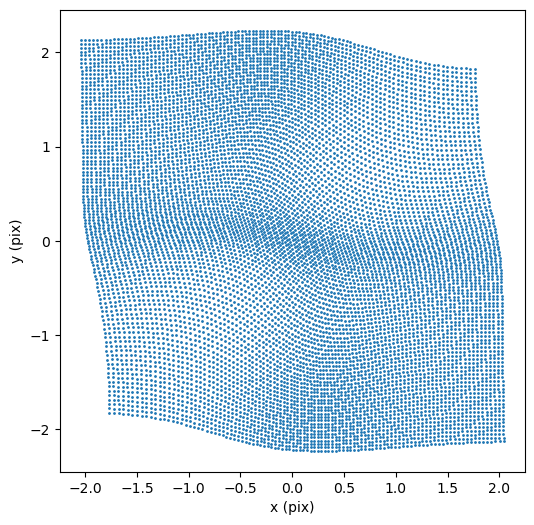

In [69]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay , s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()